In [2]:
# install necessary modules
import sys

!{sys.executable} -m pip install dlib
!{sys.executable} -m pip install mediapipe


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# necesary imports

import cv2
import mediapipe as mp
import dlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math

# Highlighting landmarks

Green - all landmarks, blue - landmarks that we are currently using

All indices here - https://www.kaggle.com/discussions/questions-and-answers/393052

I0000 00:00:1723387059.022364 8245352 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1 Pro
W0000 00:00:1723387059.026869 8289398 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1723387059.029506 8289398 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/andriimatsevytyi/anaconda3/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


nose bridge coords: (628, 533)
above nose bridge coords: (629, 515)
below nose bridge coords: (626, 558)


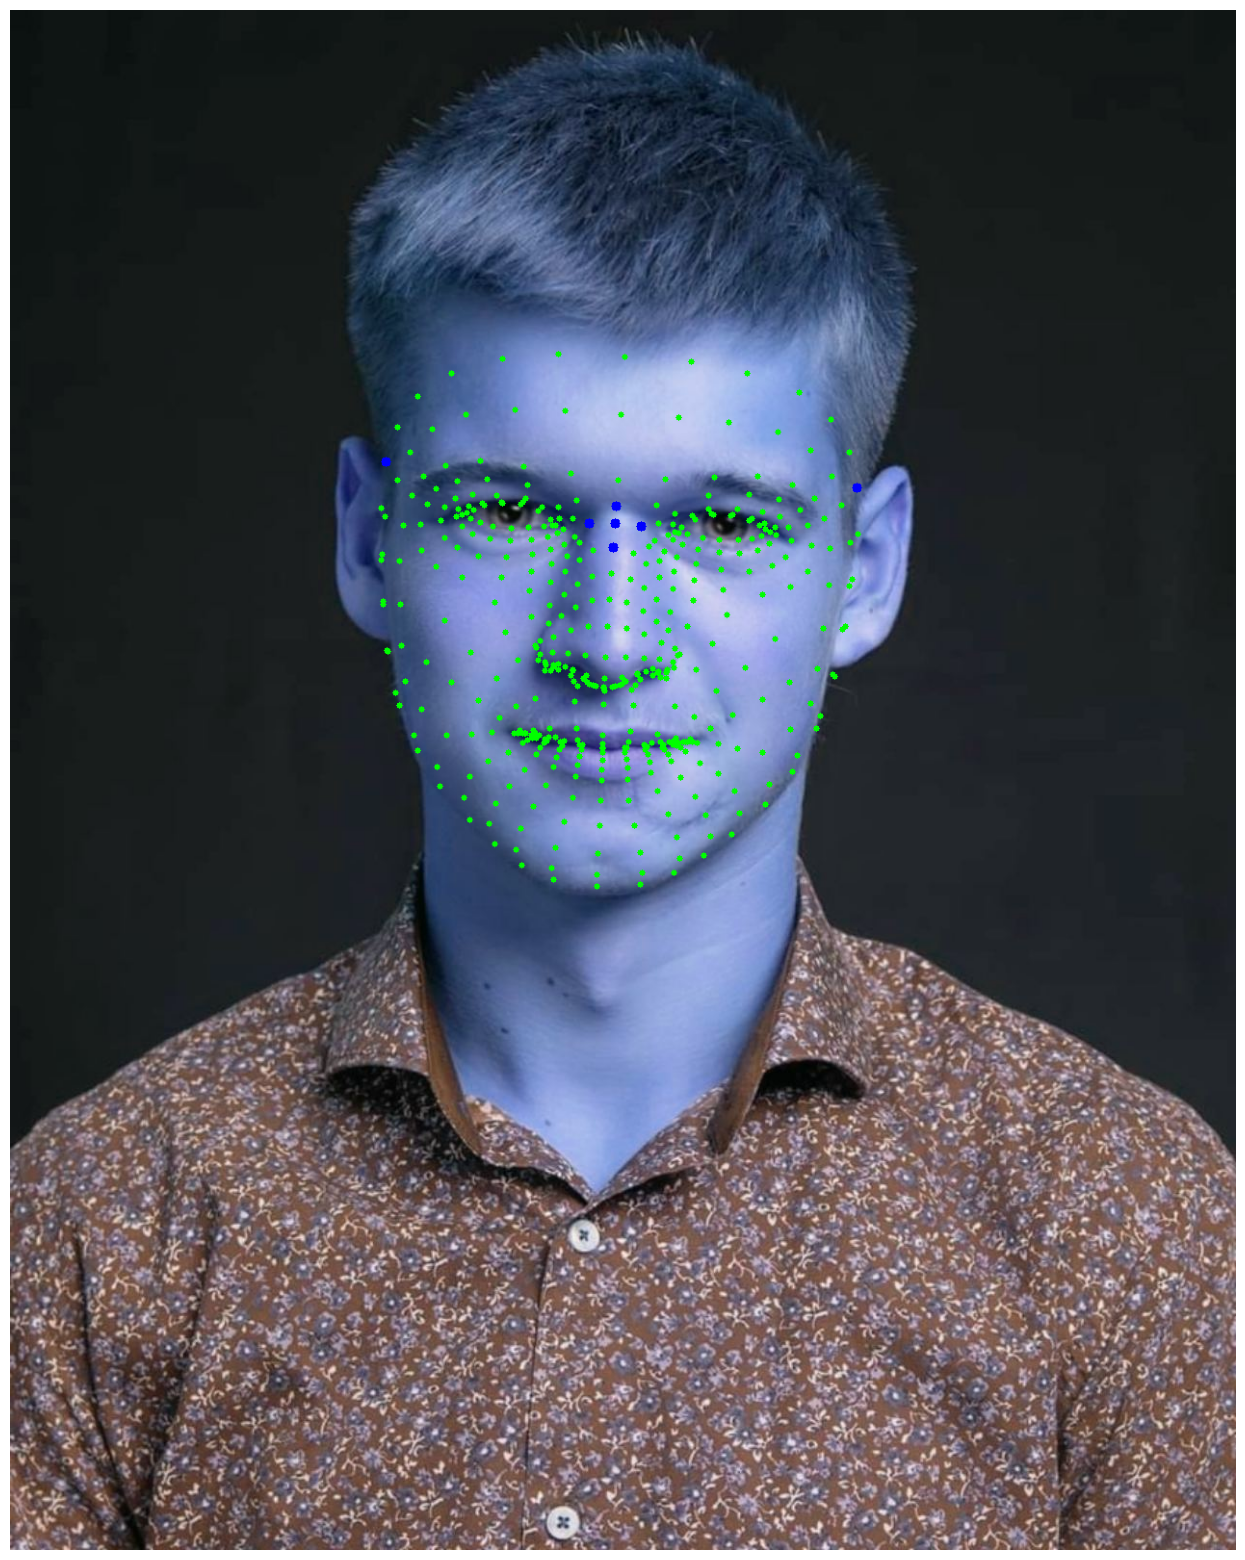

In [8]:

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

face_image_path = '/Users/andriimatsevytyi/Documents/Я/portrait photo/IMG-80e2e4f2dfeacc1079c2ef724d4214a8-V.jpg'
face_image = cv2.imread(face_image_path)

# Detect facial landmarks
def get_facial_landmarks(image):
    height, width, _ = image.shape
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    if not results.multi_face_landmarks:
        return None

    landmarks = results.multi_face_landmarks[0]
    return [(int(point.x * width), int(point.y * height)) for point in landmarks.landmark]

def find_non_transparent_edges(image):
    # Split the image into its color channels and the alpha channel
    b, g, r, alpha = cv2.split(image)
    
    # Find the indices where alpha is greater than 0 (i.e., non-transparent pixels)
    non_transparent_coords = np.argwhere(alpha > 0)
    
    # If no non-transparent pixels found, return None
    if non_transparent_coords.size == 0:
        return None, None
    
    # Get the leftmost and rightmost x-coordinates
    leftmost_x = np.min(non_transparent_coords[:, 1])
    rightmost_x = np.max(non_transparent_coords[:, 1])
    
    return leftmost_x, rightmost_x

face_landmarks = get_facial_landmarks(face_image)
if not face_landmarks:
    raise Exception("No face detected in the image")

# Draw all landmarks
for idx, landmark in enumerate(face_landmarks):
    cv2.circle(face_image, landmark, 3, (0, 255, 0), -1)

    
# Define the landmarks of interest
landmarks_of_interest = [6, 8, 168, 162, 193, 417, 389]  # Nose bridge, left ear area, right ear area

print("nose bridge coords: " + str(face_landmarks[168]))
print("above nose bridge coords: " + str(face_landmarks[8]))
print("below nose bridge coords: " + str(face_landmarks[6]))

# Draw landmarks on the image

for idx in landmarks_of_interest:
    cv2.circle(face_image, face_landmarks[idx], 5, (0, 0, 255), -1)  # Red circles

# Display the image with landmarks
plt.figure(figsize=(20, 20))
plt.imshow(face_image, cmap='gray')
plt.axis('off')
plt.show()

# Fitting glasses on the face

1. compare glasses'  and person's face bridge sizes and pick necessary scenario (https://www.clearly.com.au/thelook/wp-content/uploads/2014/07/Blog.jpg)
2. match nose and point between two landmarks in the center
3. calculate dp width of face, match it to person's bridge size and appropriately resize glassses
4. calculate rotation angle
5. generate photo

Scenarios:
- #### Bridge on glasses corresponds with face bridge:

Match nose bridge on the photo (landmark #168) and lowest center part of segmentation mask of glasses

Note: some glasses have too thin bridges which are problematic to be segmented, but somehow on each glasses we there is being segmented a part just belowbridge (like on this photo below, highlighted in red), so we may use its top central point

<img src="../assets/bad_nose_bar_extraction.png" width=300/>

- #### Face nose bridge is too big (glasses can't fit there and have to go higher, i.e. my case)

locate glasses so that their nose bridge (its middle point) locates above the nose bridge (landmark #8)


- #### Face nose bridge is too small (glasses drop below)

locate glasses on next landmarks below the nose bridge until its width matches the glasses bridge (I didn't figure out how to find out by now)

left ear area:  (390, 469)
right ear area:  (879, 496)
clockwise rotation angle:  -0.05515871592817881
actual face width:  489.74483151943525
545.5449557453379
act.bridge:  23.5
488.6921321241012
(1500, 1500, 4) => (544, 545, 4)
(760, 612) => (273, 225)
(356, 290)


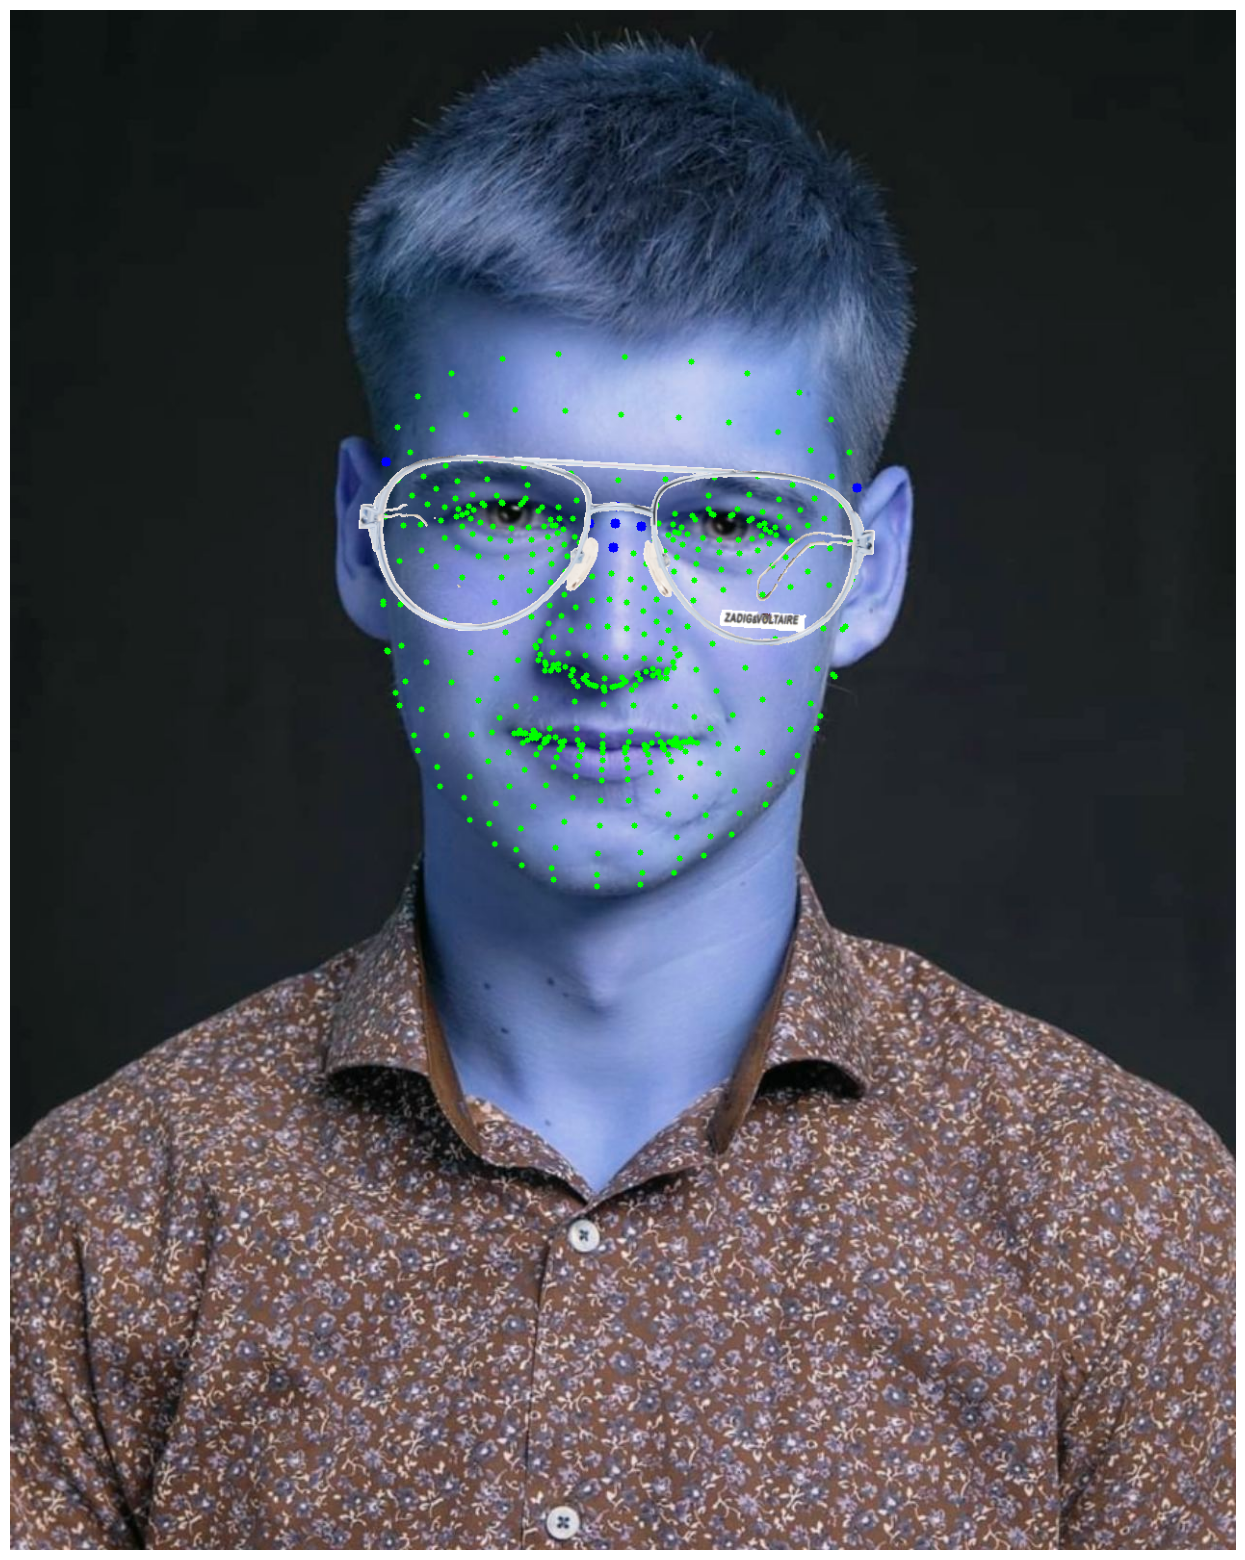

In [64]:

#glasses_image_path = '../../glasses preparation/results/preserve-nose-bar-NLP/190605168448_01.png'
glasses_image_path = '../../glasses preparation/results/preserve-nose-bar-NLP/190605154458_01.png'
#glasses_image_path = '../../glasses preparation/results/preserve-nose-bar-NLP/190605165669_01.png'

glasses_image = cv2.imread(glasses_image_path, cv2.IMREAD_UNCHANGED)  # Load with alpha channel


# Landmarks for fitting glasses
nose_tip_landmark = 1
nose_bridge_landmarks = [6, 195]
left_face_width_landmark = 234
right_face_width_landmark = 454
left_cheekbone_landmark = 50
right_cheekbone_landmark = 280
upper_nose_landmark = 6
lower_nose_landmark = 2

# Extract relevant landmarks
nose_tip = face_landmarks[nose_tip_landmark]
nose_bridge = face_landmarks[nose_bridge_landmarks[0]]
top_bar = face_landmarks[nose_bridge_landmarks[1]]
left_face_width = face_landmarks[left_face_width_landmark]
right_face_width = face_landmarks[right_face_width_landmark]
left_cheekbone = face_landmarks[left_cheekbone_landmark]
right_cheekbone = face_landmarks[right_cheekbone_landmark]
upper_nose = face_landmarks[upper_nose_landmark]
lower_nose = face_landmarks[lower_nose_landmark]

# Calculate the glasses' width and height
glasses_width = np.linalg.norm(np.array(right_face_width) - np.array(left_face_width))
glasses_height = int(glasses_width * (glasses_image.shape[0] / glasses_image.shape[1]))


print("left ear area: ", face_landmarks[162])
print("right ear area: ", face_landmarks[389])

# finding face totation (roll axis) angle clockwise in radians
# will be useful when rotating glasses to align with face
# formula is arctan { (left_landmark.y - right_landmark.y) / (right_landmark.x - left_landmark.x)) }

rot_angle = math.atan((face_landmarks[162][1] - face_landmarks[389][1])/(face_landmarks[389][0] - face_landmarks[162][0]))
print("clockwise rotation angle: ", rot_angle)

# finding actual face width
# will be useful when scaling glasses to necessary width
# formula is arctan { (left_landmark.y - right_landmark.y) / (right_landmark.x - left_landmark.x)) }

dp_face_width = math.sqrt((face_landmarks[162][1] - face_landmarks[389][1])**2 + (face_landmarks[389][0] - face_landmarks[162][0])**2)
print("actual face width: ", dp_face_width)

# formula for scaling glasses in accordance to their width and face width. Now they are scaled to match the face
# measure your nose bridge (it is the edge of the nose usually located between inside eye tips)
# glasses width = dp face width / dp bridge length * actual bridge length * full glasses width / bridge glasses length
dp_face_bridge = face_landmarks[417][0] - face_landmarks[193][0]
act_bridge = 23.5  # person has to measure, I inputed my result and later caluclated approximate front projection (x_p = x / math.sqrt(2))
glasses_bridge = 17 #from dataset .xls on gdrive, column 'Y'
full_width = 135 #from dataset .xls on gdrive, column 'Z'

new_glasses_width = dp_face_width / dp_face_bridge * act_bridge / math.sqrt(2) / full_width * glasses_width

#TODO: cases depending on bridge vs top bar on glasses (https://www.clearly.com.au/thelook/wp-content/uploads/2014/07/Blog.jpg)

print(new_glasses_width)

print("act.bridge: ", act_bridge)

# Resize glasses image
glasses_resized = cv2.resize(glasses_image, (int(new_glasses_width), int(glasses_height*new_glasses_width/glasses_width)), interpolation=cv2.INTER_AREA)

print(glasses_width)

# coordinates of nose bridge on glasses
# calculated in another notebook (when removing temples)
higher_bridge = (760, 612)
lower_bridge = (750, 630)

# Rotate glasses image
M = cv2.getRotationMatrix2D((glasses_resized.shape[1] // 2, glasses_resized.shape[0] // 2), rot_angle * 180 / math.pi, 1)
glasses_rotated = cv2.warpAffine(glasses_resized, M, (glasses_resized.shape[1], glasses_resized.shape[0]), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)


#TODO: complete

# translation:
# (750, 630) => (629, 515)

if abs(act_bridge - glasses_bridge) < 3:
    # default case
    converted_coords = (int(lower_bridge[0] / glasses_image.shape[0] * glasses_rotated.shape[0]), int(lower_bridge[1] / glasses_image.shape[1] * glasses_rotated.shape[1]))
    top_left = (628 - converted_coords[0], 533 - converted_coords[1])
elif act_bridge > glasses_bridge:
    # face nose bridge is too big
    converted_coords = (int((higher_bridge[0]+lower_bridge[0]) / 2 / glasses_image.shape[0] * glasses_rotated.shape[0]), int((higher_bridge[1]+lower_bridge[1]) / 2 / glasses_image.shape[1] * glasses_rotated.shape[1]))
    top_left = (629 - converted_coords[0], 515 - converted_coords[1])
else:
    # face nose bridge is too small (pick one level lower)
    converted_coords = (int(lower_bridge[0] / glasses_image.shape[0] * glasses_rotated.shape[0]), int(lower_bridge[1] / glasses_image.shape[1] * glasses_rotated.shape[1]))
    top_left = (626 - converted_coords[0], 558 - converted_coords[1])

print(glasses_image.shape, "=>", glasses_rotated.shape)

print(higher_bridge, "=>", converted_coords)

print(top_left)

# Overlay glasses on face image
overlay_image = face_image.copy()
for i in range(glasses_rotated.shape[0]):
    for j in range(glasses_rotated.shape[1]):
        if glasses_rotated[i, j, 3] > 0:  # Alpha channel check
            y, x = top_left[1] + i, top_left[0] + j
            if 0 <= y < overlay_image.shape[0] and 0 <= x < overlay_image.shape[1]:
                overlay_image[y, x] = glasses_rotated[i, j, :3]

# Display the final image
plt.figure(figsize=(20, 20))
plt.imshow(overlay_image, cmap='gray')
plt.axis('off')
plt.show()
